# Conda Performance Analysis

This notebook analyzes performance metrics from conda operations.

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Load Data

In [2]:
# Load the CSV file
df = pd.read_csv('../data/report.csv')

# Convert time columns from nanoseconds to seconds for better readability
df['total_time_sec'] = df['total_time'] / 1e9

# Convert memory from bytes to MB
df['max_memory_mb'] = df['max_memory_usage'] / (1024 * 1024)

# Convert bytes to MB
df['bytes_recv_mb'] = df['bytes_recv'] / (1024 * 1024)
df['bytes_sent_mb'] = df['bytes_sent'] / (1024 * 1024)

df.head()

,name,command,bytes_recv,bytes_sent,user_time,cpu_time,total_time,max_memory_usage,return_code,total_time_sec,max_memory_mb,bytes_recv_mb,bytes_sent_mb
0,set_config,python -m conda config --set plugins.use_shard...,260,0,0.00,0.00,501810917,290816,0,0.501811,0.277344,0.000248,0.000000
1,conda_create_python_conda_forge_sharded_cold,python -m conda create --name profile-env --ch...,56133538,639339,2.80,1.45,10561763505,219820032,0,10.561764,209.636719,53.533113,0.609721
2,clean,python -m conda clean --all --yes,0,0,0.00,0.00,503711417,290816,0,0.503711,0.277344,0.000000,0.000000
3,conda_create_python_conda_forge_sharded_cold,python -m conda create --name profile-env --ch...,3290218,419895,1.35,0.27,4016830336,129052672,0,4.016830,123.074219,3.137796,0.400443
4,clean,python -m conda clean --all --yes,0,0,0.00,0.00,504733667,290816,0,0.504734,0.277344,0.000000,0.000000


## Overview Statistics

In [3]:
df.describe()

,bytes_recv,bytes_sent,user_time,cpu_time,total_time,max_memory_usage,return_code,total_time_sec,max_memory_mb,bytes_recv_mb,bytes_sent_mb
count,1.900000e+01,19.000000,19.000000,19.000000,1.900000e+01,1.900000e+01,19.0,19.000000,19.000000,19.000000,19.000000
mean,1.312247e+07,113506.210526,2.131579,0.452632,4.708442e+09,3.210658e+08,0.0,4.708442,306.192229,12.514566,0.108248
std,2.733211e+07,190753.510597,2.391304,0.584207,4.972426e+09,3.656418e+08,0.0,4.972426,348.703197,26.065933,0.181917
min,0.000000e+00,0.000000,0.000000,0.000000,5.018109e+08,2.785280e+05,0.0,0.501811,0.265625,0.000000,0.000000
25%,0.000000e+00,0.000000,0.000000,0.000000,5.058408e+08,2.908160e+05,0.0,0.505841,0.277344,0.000000,0.000000
50%,2.600000e+02,0.000000,1.110000,0.180000,2.010425e+09,1.951171e+08,0.0,2.010425,186.078125,0.000248,0.000000
75%,3.289772e+06,138333.000000,4.205000,0.600000,6.533189e+09,8.189317e+08,0.0,6.533189,780.994141,3.137371,0.131925
max,9.819155e+07,639339.000000,6.980000,1.970000,1.457888e+10,8.611226e+08,0.0,14.578880,821.230469,93.642763,0.609721


## Execution Time by Operation

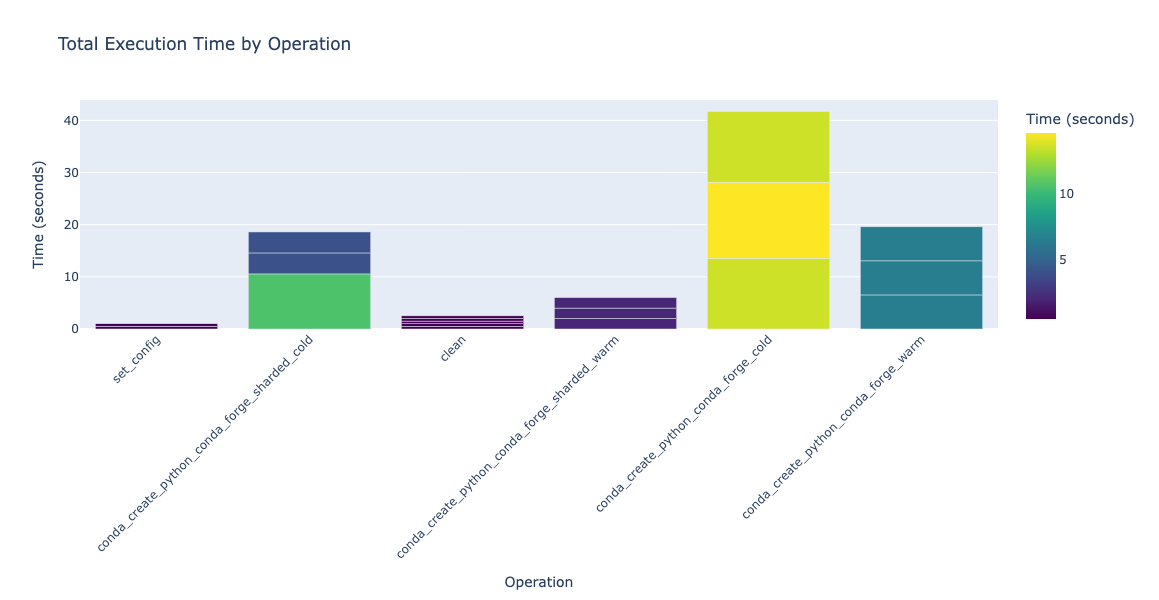

In [4]:
# Bar chart of total time by operation name
fig = px.bar(
    df,
    x='name',
    y='total_time_sec',
    title='Total Execution Time by Operation',
    labels={'total_time_sec': 'Time (seconds)', 'name': 'Operation'},
    color='total_time_sec',
    color_continuous_scale='viridis'
)
fig.update_layout(xaxis_tickangle=-45, height=600)
fig.show()

## Memory Usage Analysis

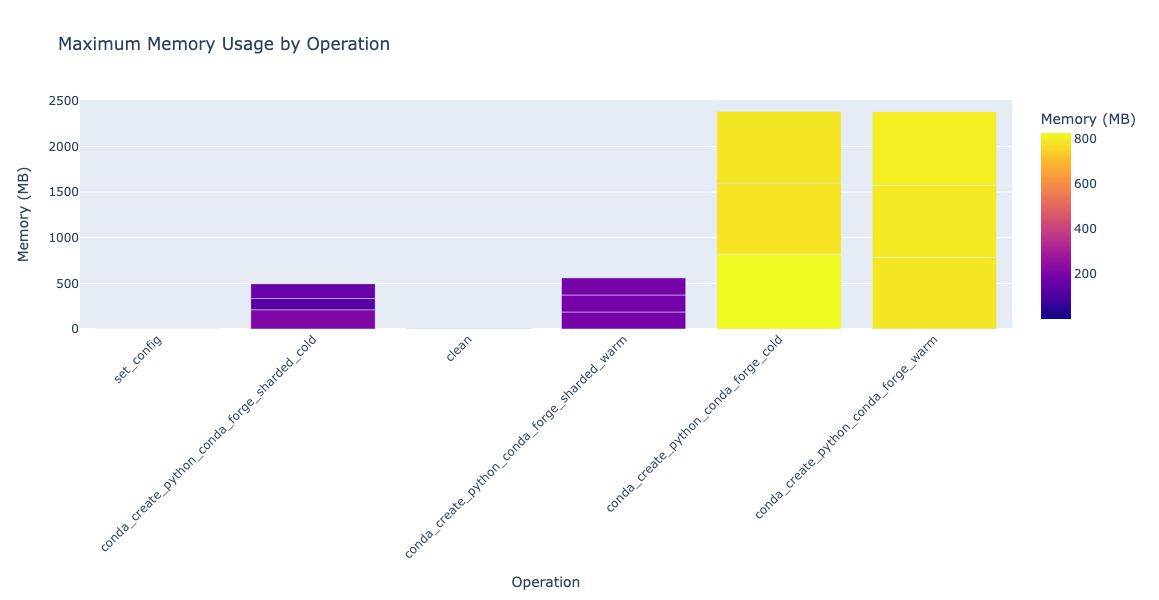

In [5]:
# Memory usage by operation
fig = px.bar(
    df,
    x='name',
    y='max_memory_mb',
    title='Maximum Memory Usage by Operation',
    labels={'max_memory_mb': 'Memory (MB)', 'name': 'Operation'},
    color='max_memory_mb',
    color_continuous_scale='plasma'
)
fig.update_layout(xaxis_tickangle=-45, height=600)
fig.show()

## Network Activity

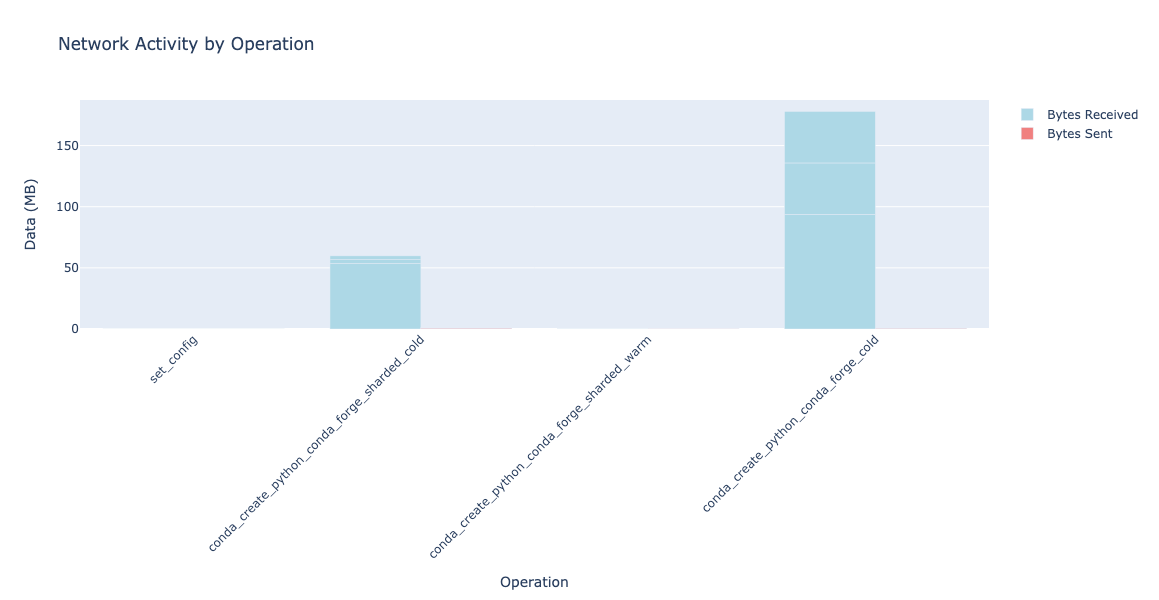

In [6]:
# Filter out operations with no network activity for clearer visualization
df_network = df[(df['bytes_recv'] > 0) | (df['bytes_sent'] > 0)].copy()

# Grouped bar chart for bytes received vs sent
fig = go.Figure()
fig.add_trace(go.Bar(
    name='Bytes Received',
    x=df_network['name'],
    y=df_network['bytes_recv_mb'],
    marker_color='lightblue'
))
fig.add_trace(go.Bar(
    name='Bytes Sent',
    x=df_network['name'],
    y=df_network['bytes_sent_mb'],
    marker_color='lightcoral'
))

fig.update_layout(
    title='Network Activity by Operation',
    xaxis_title='Operation',
    yaxis_title='Data (MB)',
    barmode='group',
    xaxis_tickangle=-45,
    height=600
)
fig.show()

## CPU Time vs User Time

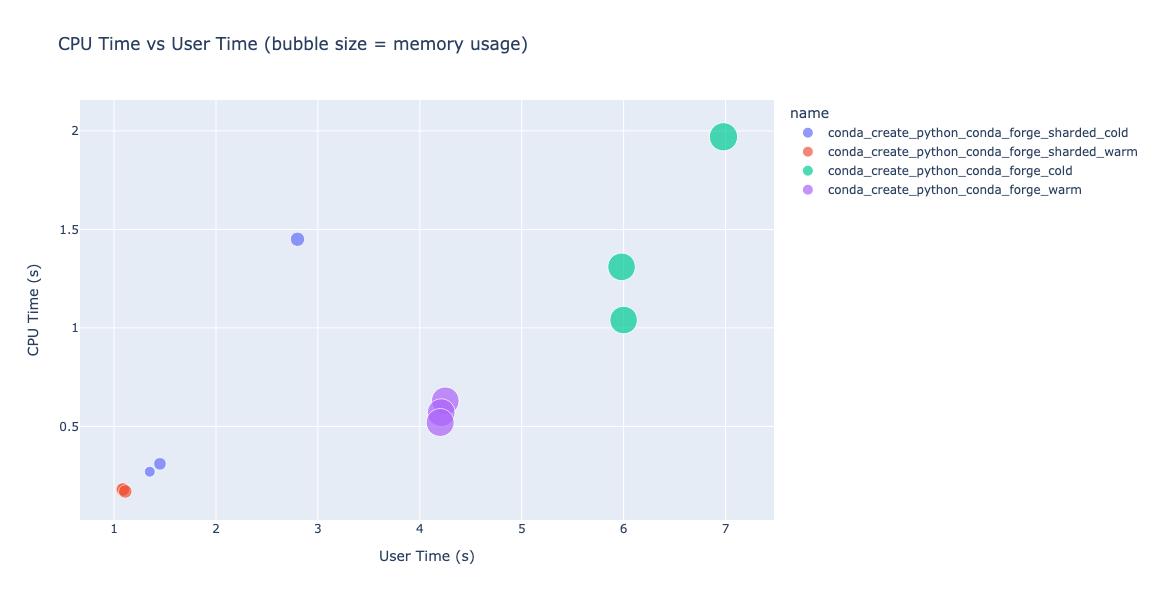

In [7]:
# Scatter plot showing relationship between user time and CPU time
df_with_time = df[(df['user_time'] > 0) | (df['cpu_time'] > 0)].copy()

fig = px.scatter(
    df_with_time,
    x='user_time',
    y='cpu_time',
    size='max_memory_mb',
    color='name',
    hover_data=['total_time_sec'],
    title='CPU Time vs User Time (bubble size = memory usage)',
    labels={'user_time': 'User Time (s)', 'cpu_time': 'CPU Time (s)'}
)
fig.update_layout(height=600)
fig.show()

## Cold vs Warm Performance Comparison

/var/folders/f0/45_t0scx2qn0dfmqyktxrs040000gn/T/ipykernel_3665/253224721.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



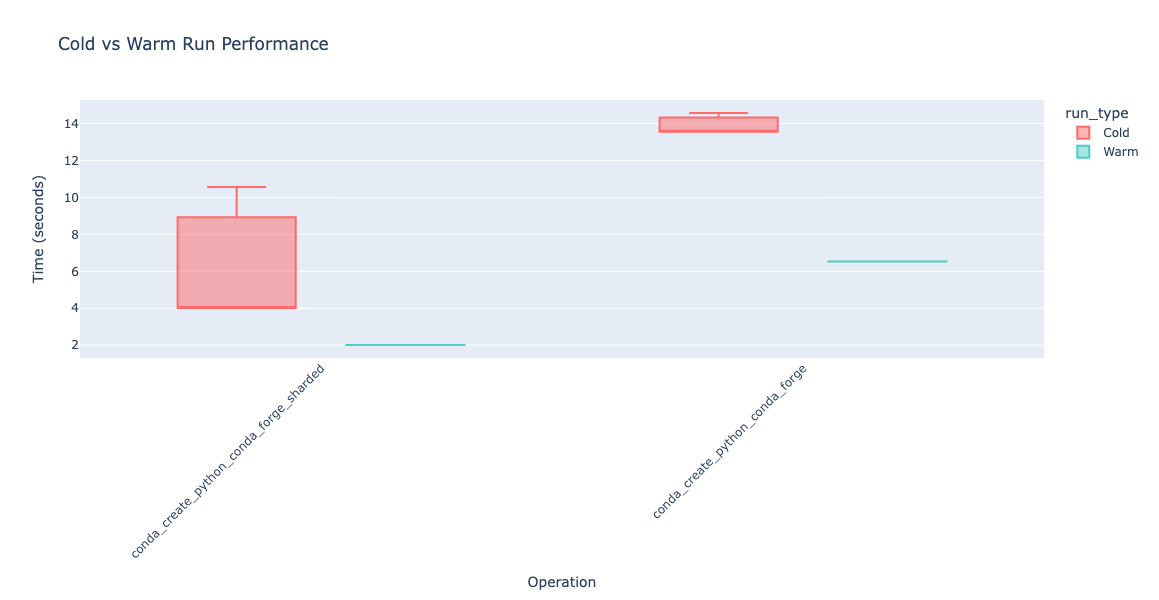

In [8]:
# Compare cold vs warm runs
df['run_type'] = df['name'].apply(lambda x: 'Cold' if 'cold' in x else ('Warm' if 'warm' in x else 'Other'))
df_comparison = df[df['run_type'].isin(['Cold', 'Warm'])]

# Extract base operation name
df_comparison['base_name'] = df_comparison['name'].str.replace('_cold', '').str.replace('_warm', '')

fig = px.box(
    df_comparison,
    x='base_name',
    y='total_time_sec',
    color='run_type',
    title='Cold vs Warm Run Performance',
    labels={'total_time_sec': 'Time (seconds)', 'base_name': 'Operation'},
    color_discrete_map={'Cold': '#FF6B6B', 'Warm': '#4ECDC4'}
)
fig.update_layout(xaxis_tickangle=-45, height=600)
fig.show()

## Summary Statistics by Operation Type

In [ ]:
# Create an example graph to export
fig = px.bar(
    df_comparison,
    x='base_name',
    y='total_time_sec',
    color='run_type',
    title='Cold vs Warm Run Performance',
    labels={'total_time_sec': 'Time (seconds)', 'base_name': 'Operation'},
    color_discrete_map={'Cold': '#FF6B6B', 'Warm': '#4ECDC4'}
)
fig.update_layout(xaxis_tickangle=-45, height=600)

# Export as standalone HTML file (includes all JS, fully self-contained)
fig.write_html('../exports/cold_vs_warm_performance.html')

# OR: Export as a div (for embedding in existing HTML pages)
html_div = fig.to_html(
    include_plotlyjs='cdn',  # Use CDN for Plotly.js (smaller file)
    div_id='cold-warm-chart',  # Custom div ID
    full_html=False  # Only export the div, not full HTML page
)

# Save the div to a file
with open('../exports/cold_vs_warm_performance_div.html', 'w') as f:
    f.write(html_div)

print("Exported graphs to ../exports/")
print("- cold_vs_warm_performance.html (standalone, embed with <iframe>)")
print("- cold_vs_warm_performance_div.html (div only, copy/paste into your page)")

## Embedding Instructions

### Option 1: Standalone HTML (use iframe)
```html
<iframe src="cold_vs_warm_performance.html" width="100%" height="650" frameborder="0"></iframe>
```

### Option 2: Direct embed (paste div into your page)
1. Add Plotly.js to your page header:
```html
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
```
2. Copy the contents of `cold_vs_warm_performance_div.html` and paste directly into your blog post

### Option 3: Export as static image (for non-interactive use)
```python
# Requires kaleido package (already in pyproject.toml)
fig.write_image('../exports/chart.png', width=1200, height=600)
fig.write_image('../exports/chart.svg', width=1200, height=600)  # SVG for crisp scaling
```